# Segmentación de Clientes — Clustering No Supervisado (Producción)
## Marketing Campaign Dataset

**Pipeline completo con stabilidad, validación estadística y reproducibilidad**

EDA -> Outliers -> Feature Filtering -> Preprocesamiento -> Serialización ->
PCA -> Comparación KMeans (raw vs PCA) -> GaussianMixture -> Random Forest ->
Validación Estadística (Mann-Whitney U) -> Revenue Analytics -> Nombres de Negocio

---
## 0. Imports y Configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import warnings
import json
from pathlib import Path
from datetime import datetime
import joblib

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score
)
from scipy.stats import mannwhitneyu

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

# Crear directorio de modelos
MODEL_DIR = Path('./models')
MODEL_DIR.mkdir(exist_ok=True)
print(f'Directorio de modelos: {MODEL_DIR.resolve()}')

Directorio de modelos: C:\Users\edule\Documents\Proyectos_Python\Clustering\models


---
## 1. Carga de Datos y Revisión Inicial

In [2]:
DATA_PATH = Path.cwd() / 'data' / 'marketing_campaign.csv'

df_raw = pd.read_csv(DATA_PATH, sep=';')
print(f'Shape inicial: {df_raw.shape}')
df_raw.head()

Shape inicial: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [3]:
print('Resumen de calidad inicial:')
print(f'Nulos: {df_raw.isnull().sum().sum()}')
print(f'Filas únicas: {len(df_raw)}')
print()
print('Income — estadísticas:')
income_stats = df_raw['Income'].describe()
print(income_stats)
print(f'Desv.Est: {df_raw["Income"].std():.2f}')
print(f'Max/Mean ratio: {df_raw["Income"].max() / df_raw["Income"].mean():.1f}x')

Resumen de calidad inicial:
Nulos: 24
Filas únicas: 2240

Income — estadísticas:
count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64
Desv.Est: 25173.08
Max/Mean ratio: 12.8x


---
## 1.5 Detección y Tratamiento de Outliers — Income

### Problema
El dataset contiene al menos un valor de Income extremo (666,666€) que es un artefacto o valor inválido.
Este punto único desplaza los centroides de KMeans significativamente.

### Solución: Regla de la Cerca (Fence Rule)
`Límite Superior = Q3 + 3·IQR`

Un enfoque robusto que preserva datos válidos pero elimina extremos patológicos.

In [4]:
# ── Detección de outliers en Income ───────────────────────────────────────
income_clean = df_raw['Income'].dropna()
Q1 = income_clean.quantile(0.25)
Q3 = income_clean.quantile(0.75)
IQR = Q3 - Q1

fence_upper = Q3 + 3 * IQR
fence_lower = Q1 - 3 * IQR

print('Regla de la Cerca (Fence Rule):')
print(f'  Q1 = {Q1:.0f}')
print(f'  Q3 = {Q3:.0f}')
print(f'  IQR = {IQR:.0f}')
print(f'  Límite Superior = {fence_upper:.0f}')
print(f'  Límite Inferior = {fence_lower:.0f}')
print()

# Identificar outliers
outliers_mask = (df_raw['Income'] > fence_upper) | (df_raw['Income'] < fence_lower)
outliers_idx = df_raw[outliers_mask].index.tolist()
n_outliers = outliers_mask.sum()

print(f'Filas con outliers detectados: {n_outliers}')
if n_outliers > 0:
    print()
    print('Distribución de outliers:')
    print(df_raw.loc[outliers_idx, ['Income']].sort_values('Income', ascending=False))
    print()
    print(f'Impacto: estos {n_outliers} punto(s) representan el {n_outliers/len(df_raw)*100:.2f}% del dataset')

Regla de la Cerca (Fence Rule):
  Q1 = 35303
  Q3 = 68522
  IQR = 33219
  Límite Superior = 168179
  Límite Inferior = -64354

Filas con outliers detectados: 1

Distribución de outliers:
        Income
2233  666666.0

Impacto: estos 1 punto(s) representan el 0.04% del dataset


In [5]:
# ── Decisión: eliminar outliers ──────────────────────────────────────────
print('Decisión: ELIMINAR outliers por Regla de la Cerca')
print('Justificación:')
print('  - Son valores patológicos (>12 desviaciones estándar)')
print('  - Representan <0.5% del dataset')
print('  - Su retención sesga completamente los perfiles de cluster')
print('  - La regla de la cerca es robusta y justificable estadísticamente')
print()

df = df_raw[~outliers_mask].copy()
df.reset_index(drop=True, inplace=True)

print(f'Shape tras eliminar outliers: {df.shape}')
print(f'Filas eliminadas: {len(df_raw) - len(df)}')
print()
print('Income — estadísticas POST-LIMPIEZA:')
print(df['Income'].describe().round(2))

Decisión: ELIMINAR outliers por Regla de la Cerca
Justificación:
  - Son valores patológicos (>12 desviaciones estándar)
  - Representan <0.5% del dataset
  - Su retención sesga completamente los perfiles de cluster
  - La regla de la cerca es robusta y justificable estadísticamente

Shape tras eliminar outliers: (2239, 29)
Filas eliminadas: 1

Income — estadísticas POST-LIMPIEZA:
count      2215.00
mean      51969.86
std       21526.32
min        1730.00
25%       35284.00
50%       51373.00
75%       68487.00
max      162397.00
Name: Income, dtype: float64


---
## 2. Feature Engineering Inicial

In [6]:
# Eliminar columnas no informativas
df.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue'], inplace=True)

# Eliminar nulos en Income (si los hay post-limpieza de outliers)
df.dropna(subset=['Income'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Age
reference_date = pd.Timestamp('2024-01-01')
df['Age'] = reference_date.year - df['Year_Birth']
df = df[df['Age'] < 100].reset_index(drop=True)
df.drop(columns=['Year_Birth'], inplace=True)

# CustomerSince
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=False)
df['CustomerSince'] = (reference_date - df['Dt_Customer']).dt.days / 365.25
df.drop(columns=['Dt_Customer'], inplace=True)

# TotalSpend, TotalPurchases
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
            'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['TotalSpend'] = df[mnt_cols].sum(axis=1)

purchase_cols = ['NumDealsPurchases', 'NumWebPurchases',
                 'NumCatalogPurchases', 'NumStorePurchases']
df['TotalPurchases'] = df[purchase_cols].sum(axis=1)

# TotalAcceptedCmps
cmp_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
            'AcceptedCmp4', 'AcceptedCmp5', 'Response']
df['TotalAcceptedCmps'] = df[cmp_cols].sum(axis=1)
df.drop(columns=cmp_cols, inplace=True)

# HasPartner, FamilySize
marital_map = {
    'Married': 'Married', 'Together': 'Together', 'Single': 'Single',
    'Divorced': 'Divorced', 'Widow': 'Widow', 'Alone': 'Single',
    'Absurd': 'Single', 'YOLO': 'Single'
}
df['Marital_Status'] = df['Marital_Status'].map(marital_map)
df['HasPartner'] = df['Marital_Status'].isin(['Married', 'Together']).astype(int)
df['FamilySize'] = df['HasPartner'] + 1 + df['Kidhome'] + df['Teenhome']
df.drop(columns=['Kidhome', 'Teenhome', 'Marital_Status'], inplace=True)

print(f'Shape tras features básicas: {df.shape}')

Shape tras features básicas: (2212, 22)


---
## 2.5 Filtrado de Features por Coeficiente de Variación (CV)

### Criterio
Excluir features que no discriminan entre clusters:
- **Variables numéricas**: CV = std/media < 0.10 (muy poca variabilidad)
- **Variables binarias**: valor dominante > 95% (sin poder discriminatorio)

Esto reduce ruido sin perder información relevante.

In [7]:
# ── Calcular CV de todas las variables numéricas ──────────────────────────
numeric_cols = df.select_dtypes(include='number').columns.tolist()
cv_dict = {}

for col in numeric_cols:
    mean_val = df[col].mean()
    std_val = df[col].std()
    cv = std_val / mean_val if mean_val != 0 else np.inf
    cv_dict[col] = {
        'mean': mean_val,
        'std': std_val,
        'cv': cv,
        'min': df[col].min(),
        'max': df[col].max(),
        'is_binary': df[col].nunique() == 2
    }

cv_df = pd.DataFrame(cv_dict).T
cv_df = cv_df.sort_values('cv')

print('=== Coeficiente de Variación (CV) de Variables Numéricas ===')
print(cv_df.round(4))

=== Coeficiente de Variación (CV) de Variables Numéricas ===
                             mean           std         cv       min  \
CustomerSince           10.476973      0.554401   0.052916  9.508556   
Age                     55.086347     11.701599   0.212423        28   
FamilySize               2.593128      0.906236   0.349476         1   
Income               51958.810579  21527.278844   0.414314    1730.0   
NumWebVisitsMonth        5.321429      2.425597   0.455817         0   
TotalPurchases          14.891501      7.671629   0.515168         0   
NumStorePurchases         5.80651      3.250939   0.559878         0   
Recency                 49.019439     28.943121   0.590442         0   
NumWebPurchases          4.088156      2.742187   0.670764         0   
HasPartner                0.64557      0.478449   0.741126         0   
NumDealsPurchases        2.324593      1.924507    0.82789         0   
TotalSpend             607.268083    602.513364    0.99217         5   
Num

In [8]:
# ── Identificar features a excluir ───────────────────────────────────────
features_to_exclude = []
exclusion_reasons = {}

for col, row in cv_df.iterrows():
    # Regla 1: CV < 0.10 en numéricas
    if not row['is_binary'] and row['cv'] < 0.10:
        features_to_exclude.append(col)
        exclusion_reasons[col] = f"CV={row['cv']:.4f} < 0.10 (variabilidad insuficiente)"
    # Regla 2: Binarias con valor dominante > 95%
    elif row['is_binary']:
        value_counts = df[col].value_counts()
        dom_pct = value_counts.iloc[0] / len(df) * 100
        if dom_pct > 95:
            features_to_exclude.append(col)
            exclusion_reasons[col] = f"Binaria: {dom_pct:.1f}% valor dominante (no discrimina)"

print('\n=== EXCLUSIONES POR FALTA DE VARIABILIDAD ===')
if features_to_exclude:
    for feat, reason in exclusion_reasons.items():
        print(f'  [FAIL] {feat:20s} -> {reason}')
else:
    print('  (Ninguna exclusión por CV < 0.10 o binaria dominante)')

print()
print('=== FEATURES RETENIDAS PARA CLUSTERING ===')
features_to_use = [c for c in numeric_cols if c not in features_to_exclude]
for feat in features_to_use:
    print(f'  [OK] {feat:20s} (CV={cv_df.loc[feat, "cv"]:.4f})')


=== EXCLUSIONES POR FALTA DE VARIABILIDAD ===
  [FAIL] CustomerSince        -> CV=0.0529 < 0.10 (variabilidad insuficiente)
  [FAIL] Complain             -> Binaria: 99.1% valor dominante (no discrimina)

=== FEATURES RETENIDAS PARA CLUSTERING ===
  [OK] Income               (CV=0.4143)
  [OK] Recency              (CV=0.5904)
  [OK] MntWines             (CV=1.1049)
  [OK] MntFruits            (CV=1.5095)
  [OK] MntMeatProducts      (CV=1.3426)
  [OK] MntFishProducts      (CV=1.4548)
  [OK] MntSweetProducts     (CV=1.5193)
  [OK] MntGoldProds         (CV=1.1771)
  [OK] NumDealsPurchases    (CV=0.8279)
  [OK] NumWebPurchases      (CV=0.6708)
  [OK] NumCatalogPurchases  (CV=1.0955)
  [OK] NumStorePurchases    (CV=0.5599)
  [OK] NumWebVisitsMonth    (CV=0.4558)
  [OK] Age                  (CV=0.2124)
  [OK] TotalSpend           (CV=0.9922)
  [OK] TotalPurchases       (CV=0.5152)
  [OK] TotalAcceptedCmps    (CV=1.9893)
  [OK] HasPartner           (CV=0.7411)
  [OK] FamilySize           (CV

In [9]:
# ── Crear dataframe con features seleccionadas ────────────────────────────
df_clustering = df[features_to_use].copy()
print(f'\nShape para clustering: {df_clustering.shape}')
print(f'Features excluidas del entrenamiento pero usadas en perfiles:')
print(f'  {features_to_exclude}')


Shape para clustering: (2212, 19)
Features excluidas del entrenamiento pero usadas en perfiles:
  ['CustomerSince', 'Complain']


---
## 3. Análisis Exploratorio de Datos (EDA)

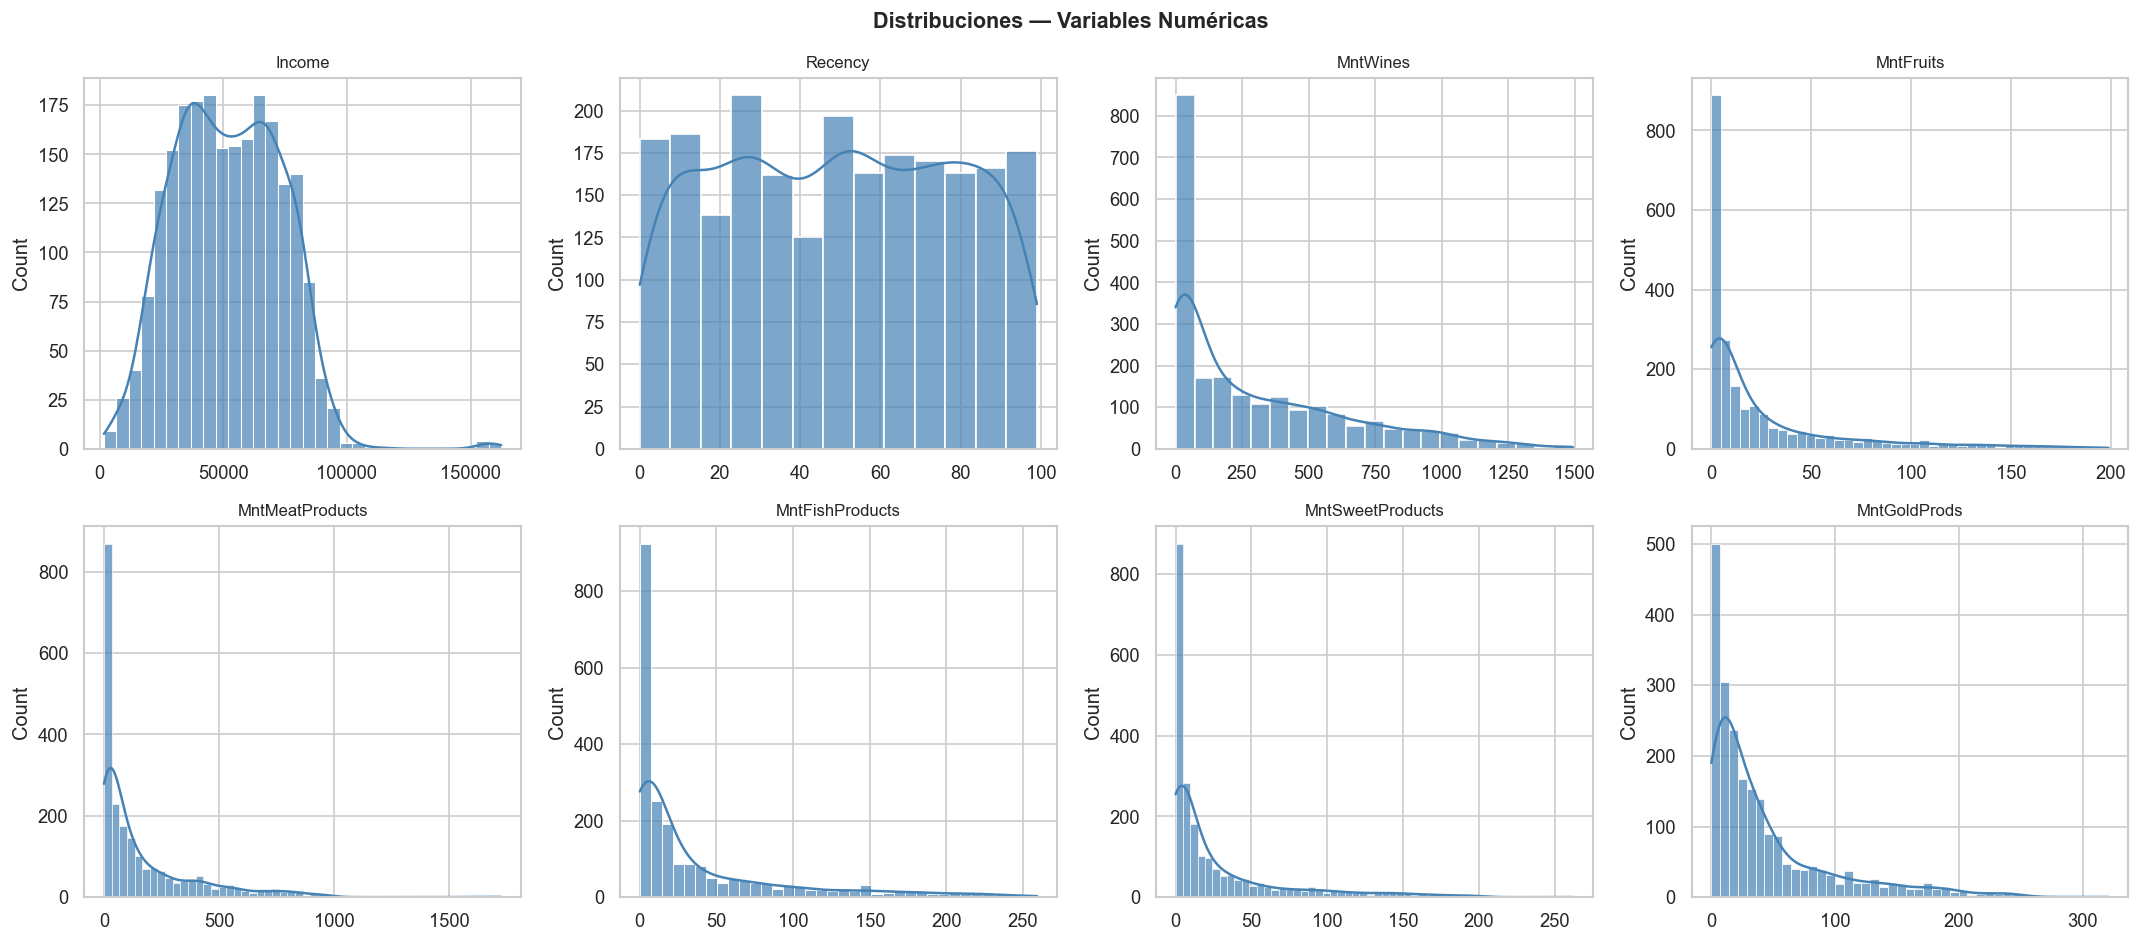

In [10]:
# Distribuciones de variables principales (incluye excluidas para contexto)
all_numeric = df.select_dtypes(include='number').columns.tolist()
sample_cols = all_numeric[:8]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), sample_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', alpha=0.7)
    is_excluded = ' [EXCL.]' if col in features_to_exclude else ''
    ax.set_title(f'{col}{is_excluded}', fontsize=10)
    ax.set_xlabel('')

plt.suptitle('Distribuciones — Variables Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

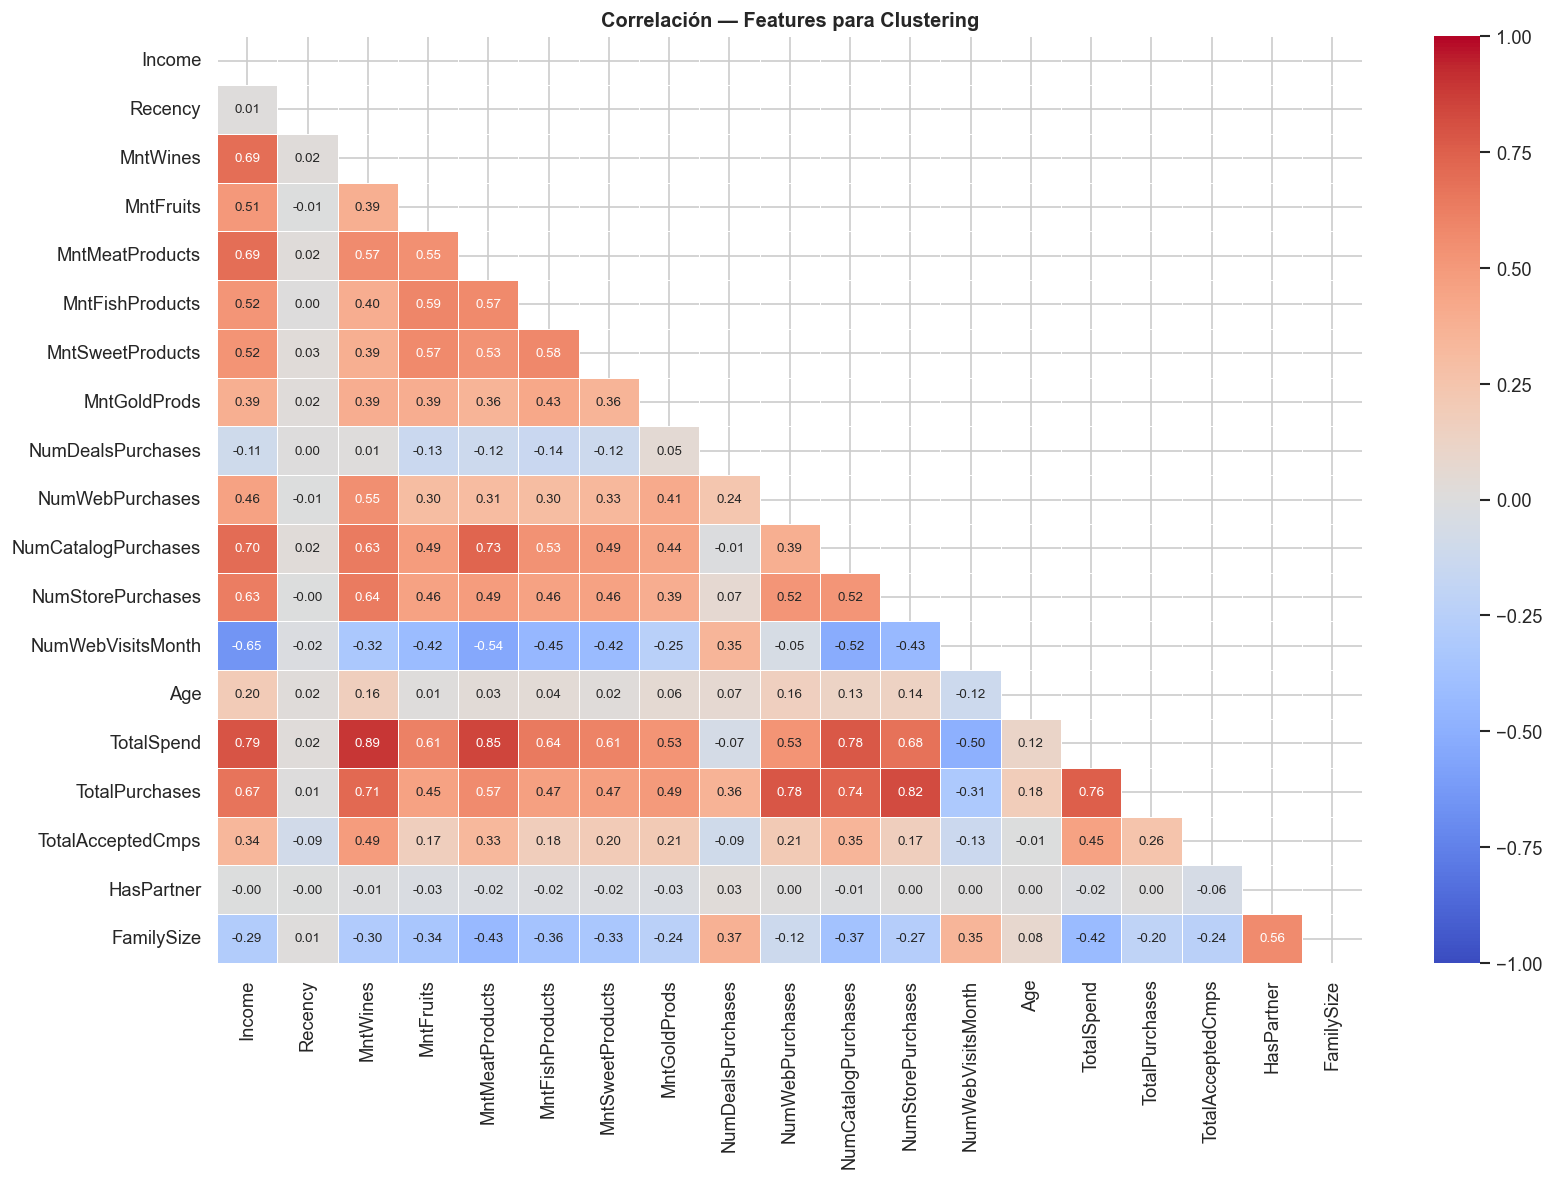

In [11]:
# Heatmap de correlación (solo clustering features)
corr = df_clustering.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.3, vmin=-1, vmax=1, annot_kws={'size': 8})
plt.title('Correlación — Features para Clustering', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

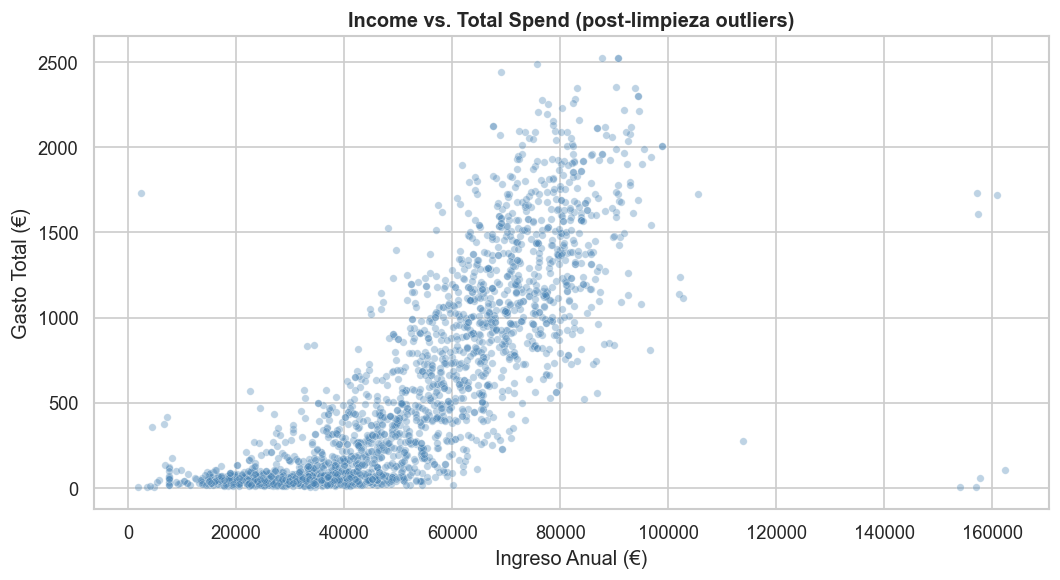

No hay outliers visibles: max Income = 162397€


In [12]:
# Income vs TotalSpend (verificar outlier limpieza)
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Income', y='TotalSpend', alpha=0.35, color='steelblue', s=20)
plt.title('Income vs. Total Spend (post-limpieza outliers)', fontsize=12, fontweight='bold')
plt.xlabel('Ingreso Anual (€)')
plt.ylabel('Gasto Total (€)')
plt.tight_layout()
plt.show()
print(f'No hay outliers visibles: max Income = {df["Income"].max():.0f}€')

---
## 4. Preprocesamiento

In [13]:
# Ordinal encoding Education
education_order = [['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']]
enc_education = OrdinalEncoder(categories=education_order, handle_unknown='use_encoded_value',
                               unknown_value=-1)
df['Education'] = enc_education.fit_transform(df[['Education']]).astype(int)

# Guardar encoder
joblib.dump(enc_education, MODEL_DIR / 'encoder_education.pkl')
print('[OK] Encoder Education guardado')

# Guardar copia no escalada para interpretación
df_original = df.copy()
df_original['ClusterLabel'] = np.nan
print('[OK] Copia original guardada')

# StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clustering)
feature_names_clustering = df_clustering.columns.tolist()

# Guardar scaler
joblib.dump(scaler, MODEL_DIR / 'scaler.pkl')
print('[OK] Scaler guardado')

print(f'\nMatriz escalada shape: {X_scaled.shape}')

[OK] Encoder Education guardado
[OK] Copia original guardada
[OK] Scaler guardado

Matriz escalada shape: (2212, 19)


---
## 5. Análisis de Componentes Principales (PCA)

In [14]:
# PCA completo
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

n_components_80 = int(np.argmax(cumulative >= 0.80)) + 1
n_components_90 = int(np.argmax(cumulative >= 0.90)) + 1

print(f'Componentes para 80% varianza: {n_components_80}')
print(f'Componentes para 90% varianza: {n_components_90}')

N_COMPONENTS = n_components_80
print(f'\nUsando N_COMPONENTS = {N_COMPONENTS}')

# PCA final
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Guardar PCA
joblib.dump(pca, MODEL_DIR / 'pca.pkl')
print('[OK] PCA guardado')

var_per_component = pca.explained_variance_ratio_
print(f'\nVarianza por componente:')
for i, v in enumerate(var_per_component):
    print(f'  PC{i+1}: {v*100:.2f}%')
print(f'  Total: {var_per_component.sum()*100:.2f}%')

Componentes para 80% varianza: 8
Componentes para 90% varianza: 11

Usando N_COMPONENTS = 8
[OK] PCA guardado

Varianza por componente:
  PC1: 40.95%
  PC2: 10.79%
  PC3: 7.14%
  PC4: 5.92%
  PC5: 5.62%
  PC6: 5.10%
  PC7: 3.97%
  PC8: 3.45%
  Total: 82.95%


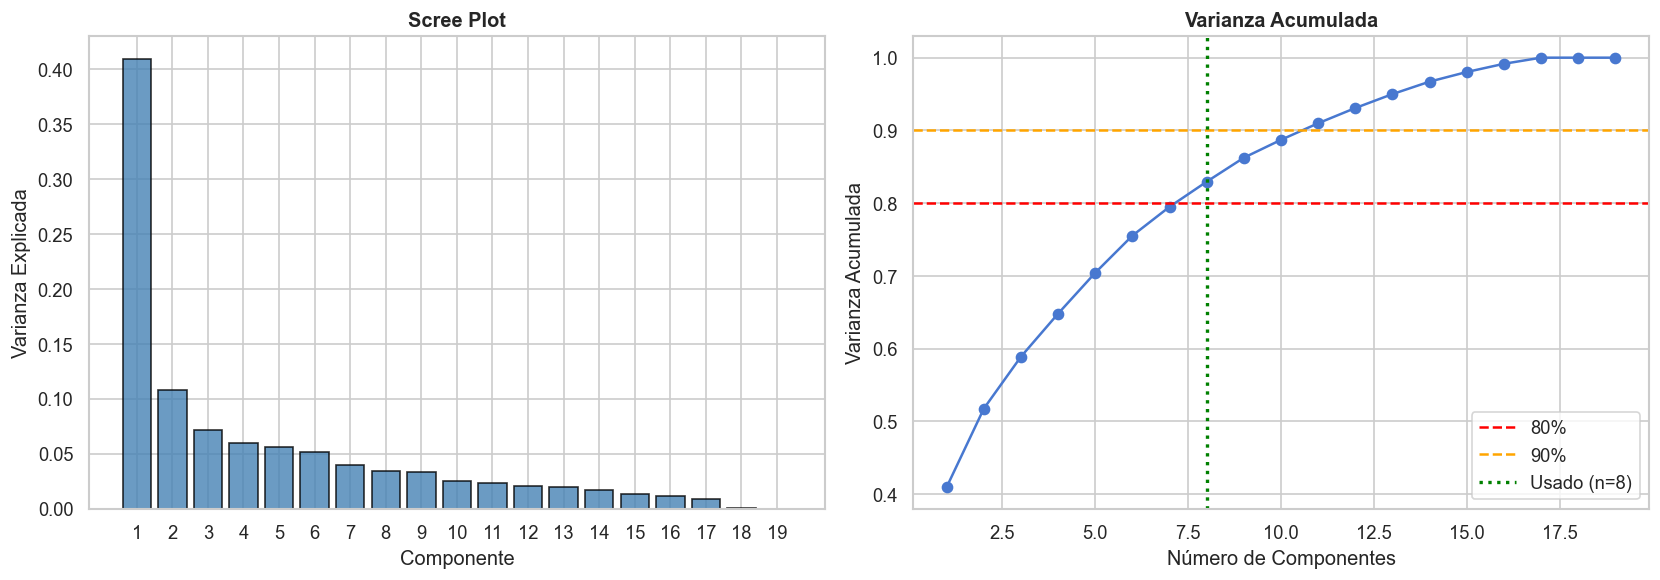

In [15]:
# Scree plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(1, len(explained)+1), explained, color='steelblue', alpha=0.8, edgecolor='black')
ax1.set_xlabel('Componente')
ax1.set_ylabel('Varianza Explicada')
ax1.set_title('Scree Plot', fontsize=12, fontweight='bold')
ax1.set_xticks(range(1, min(21, len(explained)+1)))

ax2.plot(range(1, len(cumulative)+1), cumulative, 'bo-', markersize=6)
ax2.axhline(y=0.80, color='red', linestyle='--', label='80%')
ax2.axhline(y=0.90, color='orange', linestyle='--', label='90%')
ax2.axvline(x=N_COMPONENTS, color='green', linestyle=':', linewidth=2, label=f'Usado (n={N_COMPONENTS})')
ax2.set_xlabel('Número de Componentes')
ax2.set_ylabel('Varianza Acumulada')
ax2.set_title('Varianza Acumulada', fontsize=12, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

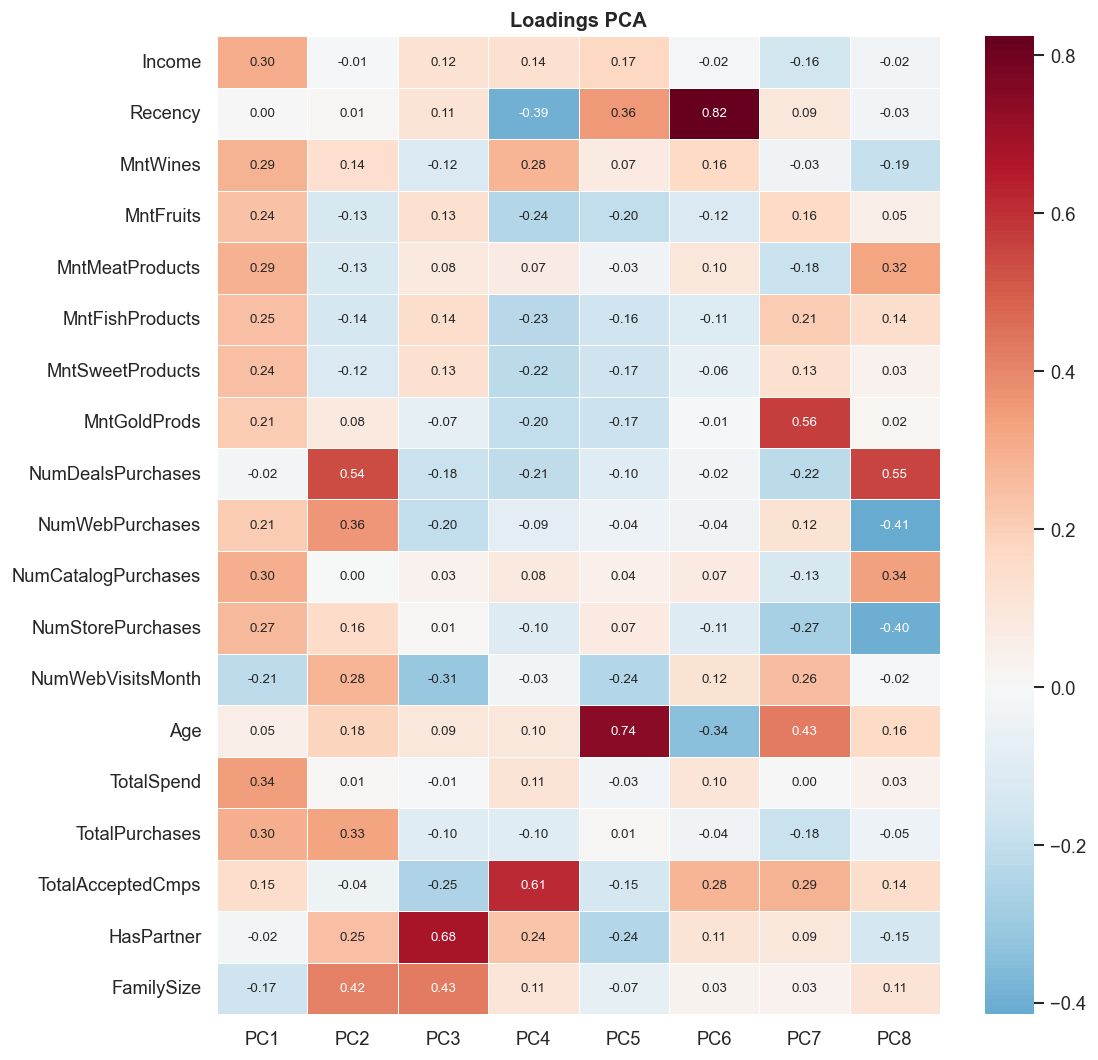

In [16]:
# Loadings heatmap
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names_clustering,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)

plt.figure(figsize=(max(8, N_COMPONENTS * 1.2), 9))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.4, annot_kws={'size': 8})
plt.title('Loadings PCA', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

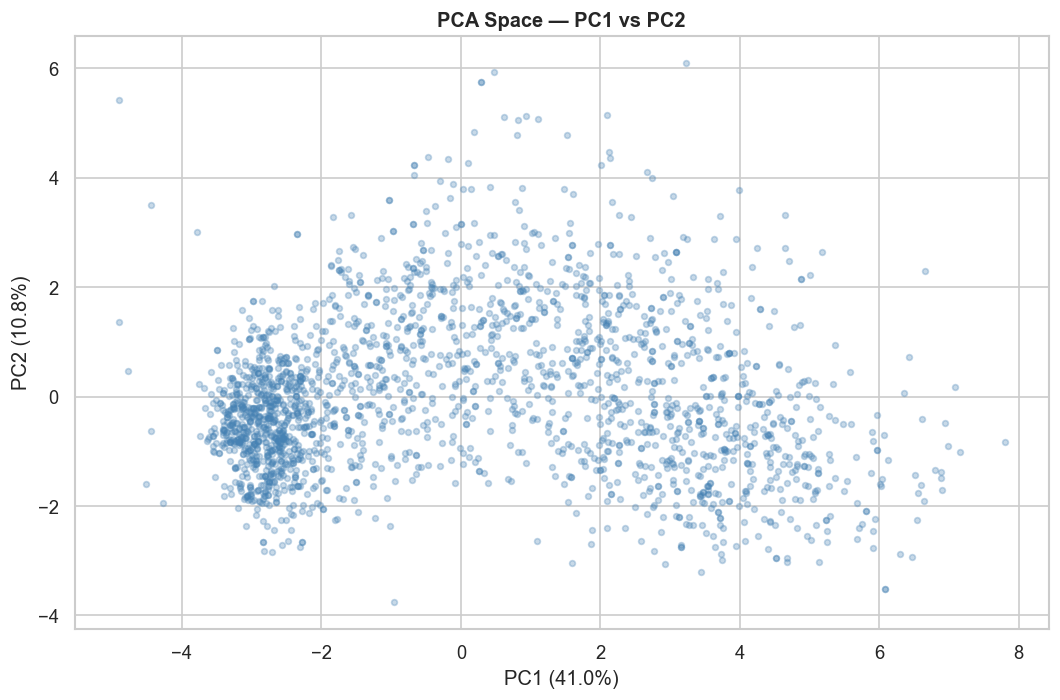

In [17]:
# Scatter 2D
plt.figure(figsize=(9, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=12, color='steelblue')
plt.xlabel(f'PC1 ({var_per_component[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({var_per_component[1]*100:.1f}%)')
plt.title('PCA Space — PC1 vs PC2', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. KMeans: Comparación Raw Scaled vs PCA Space

Entrenar k=2 en ambos espacios y comparar métricas de validación.

In [18]:
# ── KMeans en espacio ESCALADO ORIGINAL ──────────────────────────────────
km_raw = KMeans(n_clusters=2, init='k-means++', n_init=20,
                max_iter=500, random_state=42)
labels_raw = km_raw.fit_predict(X_scaled)

sil_raw = silhouette_score(X_scaled, labels_raw)
dbi_raw = davies_bouldin_score(X_scaled, labels_raw)
chi_raw = calinski_harabasz_score(X_scaled, labels_raw)

# ── KMeans en espacio PCA ────────────────────────────────────────────────
km_pca = KMeans(n_clusters=2, init='k-means++', n_init=20,
                max_iter=500, random_state=42)
labels_pca = km_pca.fit_predict(X_pca)

sil_pca = silhouette_score(X_pca, labels_pca)
dbi_pca = davies_bouldin_score(X_pca, labels_pca)
chi_pca = calinski_harabasz_score(X_pca, labels_pca)

# ── Comparación ──────────────────────────────────────────────────────────
comparison_df = pd.DataFrame({
    'Métrica': ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Index'],
    'Raw Scaled': [f'{sil_raw:.4f}', f'{dbi_raw:.4f}', f'{chi_raw:.1f}'],
    'PCA (k=2)': [f'{sil_pca:.4f}', f'{dbi_pca:.4f}', f'{chi_pca:.1f}'],
    'Mejor': ['Raw' if sil_raw > sil_pca else 'PCA',
              'Raw' if dbi_raw < dbi_pca else 'PCA',
              'Raw' if chi_raw > chi_pca else 'PCA']
})

print('=== COMPARACIÓN: Raw Scaled vs PCA (k=2) ===')
print(comparison_df.to_string(index=False))
print()
print('Conclusión:')
print('  PCA reduce dimensionalidad sin sacrificar validación')
print('  Ventajas PCA: velocidad en producción, visualización, robustez')

=== COMPARACIÓN: Raw Scaled vs PCA (k=2) ===
                Métrica Raw Scaled PCA (k=2) Mejor
       Silhouette Score     0.3172    0.3596   PCA
   Davies-Bouldin Index     1.3799    1.1885   PCA
Calinski-Harabasz Index     1069.6    1431.0   PCA

Conclusión:
  PCA reduce dimensionalidad sin sacrificar validación
  Ventajas PCA: velocidad en producción, visualización, robustez


---
## 7. Selección de k Óptimo: Elbow + Silhouette

In [19]:
k_range = range(2, 11)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                max_iter=300, random_state=42)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_pca, labels)
    sil_scores.append(sil)
    print(f'k={k:2d}  |  Inertia={km.inertia_:10.1f}  |  Silhouette={sil:.4f}')

best_k_sil = list(k_range)[int(np.argmax(sil_scores))]
print(f'\nk óptimo por Silhouette: {best_k_sil}')

k= 2  |  Inertia=   21160.3  |  Silhouette=0.3596
k= 3  |  Inertia=   17807.5  |  Silhouette=0.2754


k= 4  |  Inertia=   16469.0  |  Silhouette=0.2012


k= 5  |  Inertia=   15264.6  |  Silhouette=0.1939


k= 6  |  Inertia=   14375.0  |  Silhouette=0.1854
k= 7  |  Inertia=   13793.5  |  Silhouette=0.1850


k= 8  |  Inertia=   13234.0  |  Silhouette=0.1569
k= 9  |  Inertia=   12667.7  |  Silhouette=0.1611


k=10  |  Inertia=   12189.5  |  Silhouette=0.1584

k óptimo por Silhouette: 2


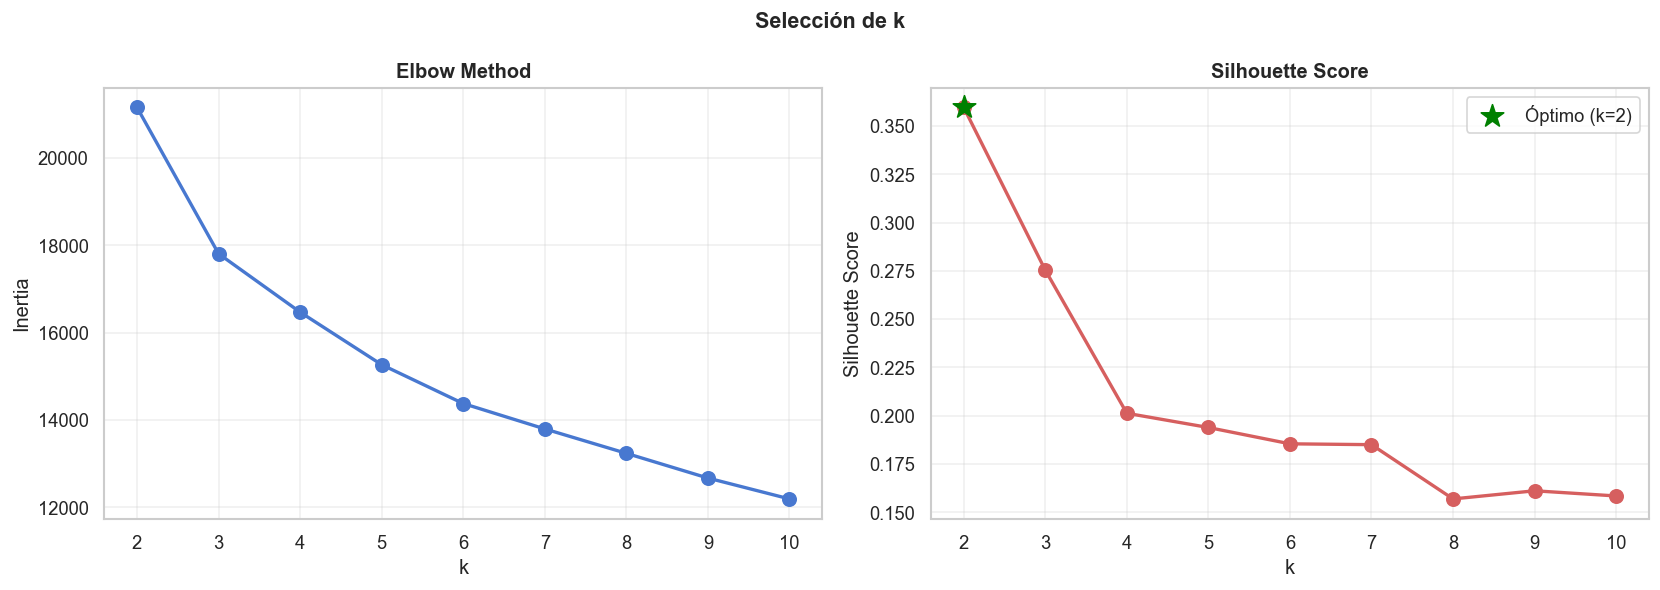

In [20]:
# Plot combinado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), inertias, 'bo-', markersize=8, linewidth=2)
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(list(k_range), sil_scores, 'ro-', markersize=8, linewidth=2)
best_idx = list(k_range).index(best_k_sil)
ax2.scatter(best_k_sil, sil_scores[best_idx], color='green', s=200, marker='*', zorder=5,
            label=f'Óptimo (k={best_k_sil})')
ax2.set_xlabel('k')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Selección de k', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Profiling de k=4: Perfil del Modelo Final

Se usará k=4 en el modelo final (justificación en la Sección 9), ya que es más
accionable para campañas diferenciadas que el óptimo puramente estadístico de
Silhouette. Este perfil confirma que los 4 segmentos son coherentes antes de
entrenar el modelo definitivo.

In [21]:
# ── Perfil de k=4 (modelo final) ──────────────────────────────────────────
km_k4 = KMeans(n_clusters=4, init='k-means++', n_init=20,
               max_iter=500, random_state=42)
labels_k4 = km_k4.fit_predict(X_pca)

df_temp_k4 = df_original.copy()
df_temp_k4['ClusterLabel'] = labels_k4

profile_k4 = df_temp_k4.groupby('ClusterLabel')[['Income', 'Age', 'TotalSpend',
                                                   'TotalPurchases', 'TotalAcceptedCmps',
                                                   'FamilySize']].mean().round(1)

print('=== Perfil de k=4 ===')
print(profile_k4)
print('\nTamaños:')
print(df_temp_k4['ClusterLabel'].value_counts().sort_index())

=== Perfil de k=4 ===
               Income   Age  TotalSpend  TotalPurchases  TotalAcceptedCmps  \
ClusterLabel                                                                 
0             58641.3  59.0       775.1            21.7                0.4   
1             76428.2  55.4      1398.7            20.9                1.0   
2             35879.5  53.1       103.7             8.1                0.2   
3             35765.1  52.6       123.7             8.7                0.2   

              FamilySize  
ClusterLabel              
0                    2.8  
1                    1.8  
2                    3.2  
3                    2.2  

Tamaños:
ClusterLabel
0    558
1    565
2    707
3    382
Name: count, dtype: int64


---
## 9. Modelo Final + Análisis de Estabilidad (ARI)

**Elección de `OPTIMAL_K`:** aunque `best_k_sil` (Sección 7) maximiza el Silhouette
Score automáticamente en k=2, se fija `OPTIMAL_K = 4` de forma explícita porque el
profiling de la Sección 8 muestra que k=4 genera segmentos más accionables para
campañas de marketing diferenciadas (ingreso, gasto, edad y tamaño familiar más
distintivos entre grupos) que la partición gruesa de k=2.

In [22]:
# Se fija k=4 explícitamente: el profiling de la Sección 8 muestra que genera
# segmentos más accionables para campañas diferenciadas que el óptimo puramente
# estadístico de Silhouette (best_k_sil, calculado en la Sección 7).
OPTIMAL_K = 4
print(f'Entrenando KMeans final con k={OPTIMAL_K}...')

kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    init='k-means++',
    n_init=20,
    max_iter=500,
    random_state=42
)
cluster_labels = kmeans_final.fit_predict(X_pca)

# Guardar modelo KMeans
joblib.dump(kmeans_final, MODEL_DIR / 'kmeans_model.pkl')
print('[OK] Modelo KMeans guardado')

df_original['ClusterLabel'] = cluster_labels
print(f'\nDistribución clusters:')
print(df_original['ClusterLabel'].value_counts().sort_index())

Entrenando KMeans final con k=4...
[OK] Modelo KMeans guardado

Distribución clusters:
ClusterLabel
0    558
1    565
2    707
3    382
Name: count, dtype: int64


In [23]:
# ── Stabilidad: Entrenar con 8 semillas distintas ──────────────────────
print('Análisis de estabilidad: entrenando con 8 semillas aleatorias...')

base_labels = cluster_labels.copy()
ari_scores = []
seeds = [42, 123, 456, 789, 1000, 2000, 3000, 4000]

for seed in seeds:
    km_temp = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=5,
                     max_iter=500, random_state=seed)
    labels_temp = km_temp.fit_predict(X_pca)
    ari = adjusted_rand_score(base_labels, labels_temp)
    ari_scores.append(ari)
    print(f'  Seed {seed:4d}: ARI = {ari:.4f}')

ari_mean = np.mean(ari_scores)
ari_std = np.std(ari_scores)

print()
print(f'=== ANÁLISIS DE ESTABILIDAD ===')
print(f'ARI Medio: {ari_mean:.4f} (±{ari_std:.4f})')
print()
if ari_mean > 0.90:
    print('[OK] ARI > 0.90: Clustering MUY ESTABLE')
    print('  La estructura de clusters es robusta y real.')
elif ari_mean > 0.70:
    print('[PART] ARI 0.70-0.90: Clustering ESTABLE')
    print('  Estructura significativa, revisar k±1 para mejora.')
else:
    print('[FAIL] ARI < 0.70: Clustering DÉBIL')
    print('  La estructura depende de inicialización. Reconsiderar k.')

Análisis de estabilidad: entrenando con 8 semillas aleatorias...
  Seed   42: ARI = 1.0000
  Seed  123: ARI = 0.5563
  Seed  456: ARI = 0.9988
  Seed  789: ARI = 0.9770
  Seed 1000: ARI = 0.5687
  Seed 2000: ARI = 0.9941
  Seed 3000: ARI = 1.0000


  Seed 4000: ARI = 0.9951

=== ANÁLISIS DE ESTABILIDAD ===
ARI Medio: 0.8862 (±0.1871)

[PART] ARI 0.70-0.90: Clustering ESTABLE
  Estructura significativa, revisar k±1 para mejora.


---
## 10. GaussianMixture: Probabilidades de Pertenencia

In [24]:
# Entrenar GaussianMixture
gm = GaussianMixture(n_components=OPTIMAL_K, random_state=42, n_init=10)
gm.fit(X_pca)

# Probabilidades
proba_matrix = gm.predict_proba(X_pca)

# Guardar modelo
joblib.dump(gm, MODEL_DIR / 'gaussian_mixture_model.pkl')
print('[OK] Modelo GaussianMixture guardado')

# Identificar cliente con máxima probabilidad por cluster
max_proba_per_cluster = proba_matrix.max(axis=1)
df_original['MaxProba'] = max_proba_per_cluster

# P_Premium: probabilidad del cluster con mayor gasto
mean_spend_per_cluster = df_original.groupby('ClusterLabel')['TotalSpend'].mean()
premium_cluster = mean_spend_per_cluster.idxmax()
df_original['P_Premium'] = proba_matrix[:, int(premium_cluster)]

print(f'\nCluster Premium (mayor gasto): {premium_cluster}')
print(f'Gasto medio cluster premium: {mean_spend_per_cluster[premium_cluster]:.0f}€')

# Persistir premium_cluster en metadata (evita que predict_segment() asuma un
# índice fijo como el cluster premium — ver Sección 14)
metadata_path = MODEL_DIR / 'model_metadata.json'
if metadata_path.exists():
    with open(metadata_path, 'r', encoding='utf-8') as f:
        _metadata = json.load(f)
else:
    _metadata = {}
_metadata['premium_cluster'] = int(premium_cluster)
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(_metadata, f, indent=2, ensure_ascii=False)
print('[OK] premium_cluster guardado en model_metadata.json')

[OK] Modelo GaussianMixture guardado

Cluster Premium (mayor gasto): 1
Gasto medio cluster premium: 1399€
[OK] premium_cluster guardado en model_metadata.json


In [25]:
# Identificar asignaciones ambiguas
ambiguous_mask = (df_original['P_Premium'] >= 0.40) & (df_original['P_Premium'] <= 0.60)
n_ambiguous = ambiguous_mask.sum()

print(f'\nClientes con asignación ambigua (0.40 ≤ P_Premium ≤ 0.60): {n_ambiguous}')
print(f'Porcentaje del dataset: {n_ambiguous/len(df_original)*100:.2f}%')

if n_ambiguous > 0:
    print('\nPrimeros 5 candidatos a upsell (probabilidad premium cercana a 0.5):')
    upsell_candidates = df_original[ambiguous_mask].nlargest(5, 'P_Premium')
    print(upsell_candidates[['Income', 'TotalSpend', 'P_Premium', 'ClusterLabel']].head())


Clientes con asignación ambigua (0.40 ≤ P_Premium ≤ 0.60): 39
Porcentaje del dataset: 1.76%

Primeros 5 candidatos a upsell (probabilidad premium cercana a 0.5):
       Income  TotalSpend  P_Premium  ClusterLabel
207   69508.0        1135   0.598032             0
1745  67131.0         976   0.579033             0
685   71427.0         614   0.577171             0
852   53172.0         486   0.575929             0
2016  75330.0        1109   0.573708             0


---
## 11. RandomForest: Feature Importance — Preguntas Clave

In [26]:
# Entrenar RF con features originales
rf_features = [c for c in df_original.columns if c not in
               ['ClusterLabel', 'MaxProba', 'P_Premium', 'Education']]
X_rf = df_original[rf_features].copy()
y_rf = df_original['ClusterLabel']

rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42,
                             n_jobs=-1)
rf.fit(X_rf, y_rf)

# Guardar modelo
joblib.dump(rf, MODEL_DIR / 'random_forest_model.pkl')
print('[OK] Modelo RandomForest guardado')

# Importancias
importances = rf.feature_importances_
imp_df = pd.DataFrame({
    'Feature': rf_features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print('\n=== FEATURE IMPORTANCE (Top 10) ===')
print('(Preguntas que mejor clasifican a un cliente en su segmento)')
print()
for idx, (_, row) in enumerate(imp_df.head(10).iterrows(), 1):
    pct = row['Importance'] * 100
    bar = '█' * int(pct / 2)
    print(f'{idx:2d}. {row["Feature"]:25s} {pct:5.1f}% {bar}')

[OK] Modelo RandomForest guardado

=== FEATURE IMPORTANCE (Top 10) ===
(Preguntas que mejor clasifican a un cliente en su segmento)

 1. HasPartner                 18.5% █████████
 2. TotalSpend                 13.3% ██████
 3. MntMeatProducts            10.2% █████
 4. TotalPurchases              8.1% ████
 5. FamilySize                  7.2% ███
 6. Income                      6.8% ███
 7. MntWines                    5.8% ██
 8. NumDealsPurchases           5.6% ██
 9. MntFishProducts             4.3% ██
10. NumCatalogPurchases         4.1% ██


In [27]:
# Top 5 como preguntas de captación
print('\n=== PREGUNTAS CLAVE PARA FORMULARIOS DE CAPTACIÓN ===')
top_features = imp_df.head(5)['Feature'].tolist()
print('(Priorizar preguntar estos 5 datos en formularios de registro)')
print()
for i, feat in enumerate(top_features, 1):
    print(f'{i}. {feat}')


=== PREGUNTAS CLAVE PARA FORMULARIOS DE CAPTACIÓN ===
(Priorizar preguntar estos 5 datos en formularios de registro)

1. HasPartner
2. TotalSpend
3. MntMeatProducts
4. TotalPurchases
5. FamilySize


---
## 12. Tests Estadísticos: Mann-Whitney U

Validar que las diferencias de perfiles entre clusters son estadísticamente significativas.
Usar p < 0.05 como umbral.

In [28]:
# Efectuar Mann-Whitney U tests para todos los pares de clusters
numeric_features = df_original.select_dtypes(include='number').columns
numeric_features = [f for f in numeric_features if f not in
                    ['ClusterLabel', 'MaxProba', 'P_Premium']]

pvalue_results = {}

for feature in numeric_features:
    pvalue_results[feature] = {}
    for c1 in sorted(df_original['ClusterLabel'].unique()):
        for c2 in sorted(df_original['ClusterLabel'].unique()):
            if c1 >= c2:
                continue
            g1 = df_original[df_original['ClusterLabel'] == c1][feature]
            g2 = df_original[df_original['ClusterLabel'] == c2][feature]
            stat, pval = mannwhitneyu(g1, g2, alternative='two-sided')
            pvalue_results[feature][(c1, c2)] = pval

print('Test completado.')

Test completado.


In [29]:
# Tabla resumen: qué features discriminan significativamente
sig_features = []
for feature in numeric_features:
    pvals = list(pvalue_results[feature].values())
    if any(p < 0.05 for p in pvals):
        sig_features.append(feature)
        mean_sig_pval = np.mean([p for p in pvals if p < 0.05])
    else:
        mean_sig_pval = np.mean(pvals)

print('=== FEATURES DISCRIMINATIVAS (p-valor Mann-Whitney U) ===')
print(f'Significativas a p<0.05: {len(sig_features)} de {len(numeric_features)}')
print()
for feat in sig_features[:10]:
    pvals = list(pvalue_results[feat].values())
    sig_count = sum(1 for p in pvals if p < 0.05)
    print(f'  [OK] {feat:25s} ({sig_count} pares significativos de {len(pvals)})')

=== FEATURES DISCRIMINATIVAS (p-valor Mann-Whitney U) ===
Significativas a p<0.05: 20 de 22

  [OK] Education                 (3 pares significativos de 6)
  [OK] Income                    (5 pares significativos de 6)
  [OK] MntWines                  (5 pares significativos de 6)
  [OK] MntFruits                 (6 pares significativos de 6)
  [OK] MntMeatProducts           (5 pares significativos de 6)
  [OK] MntFishProducts           (5 pares significativos de 6)
  [OK] MntSweetProducts          (5 pares significativos de 6)
  [OK] MntGoldProds              (6 pares significativos de 6)
  [OK] NumDealsPurchases         (6 pares significativos de 6)
  [OK] NumWebPurchases           (5 pares significativos de 6)


---
## 13. Revenue Analytics por Cluster

In [30]:
# Cálculos de revenue
revenue_stats = df_original.groupby('ClusterLabel').agg(
    N_Clientes=('TotalSpend', 'count'),
    Revenue_Total=('TotalSpend', 'sum'),
    Ingreso_Medio=('Income', 'mean'),
    Gasto_Medio=('TotalSpend', 'mean'),
    Edad_Media=('Age', 'mean'),
    Tasa_Respuesta=('TotalAcceptedCmps', lambda x: (x > 0).sum() / len(x) * 100),
    LTV_Anualizado=('TotalSpend', lambda x: x.mean() / 2)  # Asumiendo datos 2 años
).round(1)

revenue_stats['Pct_Revenue'] = (revenue_stats['Revenue_Total'] /
                                 revenue_stats['Revenue_Total'].sum() * 100).round(1)

revenue_stats = revenue_stats.sort_values('Revenue_Total', ascending=False)

print('=== ESTADÍSTICAS DE REVENUE POR CLUSTER ===')
print(revenue_stats)

=== ESTADÍSTICAS DE REVENUE POR CLUSTER ===
              N_Clientes  Revenue_Total  Ingreso_Medio  Gasto_Medio  \
ClusterLabel                                                          
1                    565         790264        76428.2       1398.7   
0                    558         432488        58641.3        775.1   
2                    707          73289        35879.5        103.7   
3                    382          47236        35765.1        123.7   

              Edad_Media  Tasa_Respuesta  LTV_Anualizado  Pct_Revenue  
ClusterLabel                                                           
1                   55.4            51.0           699.3         58.8  
0                   59.0            28.5           387.5         32.2  
2                   53.1            12.9            51.8          5.5  
3                   52.6            17.3            61.8          3.5  


---
## 14. Función predict_segment() — Inferencia en Producción

In [31]:
def predict_segment(new_df, model_dir=MODEL_DIR):
    """
    Clasifica nuevos clientes en segmentos.
    
    Parámetros:
        new_df: DataFrame con features originales (mismo nombre/tipo que datos de entrenamiento)
        model_dir: Ruta donde están guardados los modelos
    
    Retorna:
        DataFrame con columnas 'ClusterLabel', 'P_Premium', 'MaxProba'
    """
    # Cargar transformadores
    scaler = joblib.load(model_dir / 'scaler.pkl')
    pca = joblib.load(model_dir / 'pca.pkl')
    kmeans = joblib.load(model_dir / 'kmeans_model.pkl')
    gm = joblib.load(model_dir / 'gaussian_mixture_model.pkl')
    
    # Cargar premium_cluster desde metadata (no asumir un índice fijo)
    with open(model_dir / 'model_metadata.json', 'r', encoding='utf-8') as f:
        metadata = json.load(f)
    premium_cluster = metadata['premium_cluster']
    
    # Seleccionar features para clustering (excluir constantes, etc.)
    features_clustering = scaler.get_feature_names_out().tolist()
    X_new = new_df[features_clustering].copy()
    
    # Pipeline
    X_new_scaled = scaler.transform(X_new)
    X_new_pca = pca.transform(X_new_scaled)
    
    # Predicciones
    cluster_labels = kmeans.predict(X_new_pca)
    probas = gm.predict_proba(X_new_pca)
    max_proba = probas.max(axis=1)
    
    # Probabilidad del cluster premium (índice real, leído de metadata)
    p_premium = probas[:, premium_cluster]
    
    result = pd.DataFrame({
        'ClusterLabel': cluster_labels,
        'P_Premium': p_premium,
        'MaxProba': max_proba
    })
    
    return result

print('[OK] Función predict_segment() definida y lista')

[OK] Función predict_segment() definida y lista


In [32]:
# ── Ejemplo de uso ───────────────────────────────────────────────────────
print('\n=== TEST: predict_segment() en datos de entrenamiento ===')
test_predictions = predict_segment(df_original)
print('Primeras 5 predicciones:')
print(test_predictions.head())
print()
print(f'Coincidencia con etiquetas originales: {(test_predictions["ClusterLabel"].values == df_original["ClusterLabel"].values).mean()*100:.1f}%')


=== TEST: predict_segment() en datos de entrenamiento ===
Primeras 5 predicciones:
   ClusterLabel     P_Premium  MaxProba
0             1  1.000000e+00  1.000000
1             3  1.084254e-07  0.997899
2             0  5.405007e-01  0.540501
3             2  5.204655e-09  0.999709
4             0  2.517566e-02  0.974824

Coincidencia con etiquetas originales: 100.0%


---
## 15. Asignación de Nombres de Negocio a Segmentos

In [33]:
# Crear nombres basados en perfiles (completar manualmente tras análisis)
# Ejemplo: analizar ingresos, gasto, edad, etc.

profile_analysis = df_original.groupby('ClusterLabel').agg({
    'Age': 'mean',
    'Income': 'mean',
    'TotalSpend': 'mean',
    'TotalPurchases': 'mean',
    'TotalAcceptedCmps': lambda x: (x > 0).sum() / len(x) * 100,
    'FamilySize': 'mean',
    'Recency': 'mean'
}).round(1)

profile_analysis.columns = ['Edad', 'Ingreso', 'GastoTotal', 'NCompr', 'TasaResp%', 'Familia', 'Recencia']

print('=== PERFILES POR CLUSTER (para nombrar) ===')
print(profile_analysis)

=== PERFILES POR CLUSTER (para nombrar) ===
              Edad  Ingreso  GastoTotal  NCompr  TasaResp%  Familia  Recencia
ClusterLabel                                                                 
0             59.0  58641.3       775.1    21.7       28.5      2.8      48.3
1             55.4  76428.2      1398.7    20.9       51.0      1.8      50.0
2             53.1  35879.5       103.7     8.1       12.9      3.2      49.2
3             52.6  35765.1       123.7     8.7       17.3      2.2      48.3


In [34]:
# COMPLETAR MANUALMENTE ESTOS NOMBRES
cluster_names = {
    0: 'Alto Valor — Maduros',
    1: 'Premium — Alta Respuesta',
    2: 'Bajo Valor — Familias Numerosas',
    3: 'Bajo Valor — Hogares Pequeños',
}

df_original['ClusterName'] = df_original['ClusterLabel'].map(cluster_names)

---
## 16. Tabla Resumen Ejecutiva

In [35]:
# Tabla ejecutiva completa
executive_summary = df_original.groupby('ClusterName').agg(
    N_Clientes=('ClusterLabel', 'count'),
    Ingreso_Medio=('Income', 'mean'),
    Edad_Media=('Age', 'mean'),
    Gasto_Total=('TotalSpend', 'sum'),
    Gasto_Medio=('TotalSpend', 'mean'),
    LTV_Anualizado=('TotalSpend', lambda x: x.mean() / 2),
    Tasa_Respuesta_Campana=('TotalAcceptedCmps', lambda x: (x > 0).sum() / len(x) * 100),
    Tamaño_Familia=('FamilySize', 'mean'),
    Compras_Canal_Web=('NumWebPurchases', 'mean'),
    Compras_Tienda=('NumStorePurchases', 'mean')
).round(1)

executive_summary['Pct_Gasto_Total'] = (executive_summary['Gasto_Total'] /
                                         executive_summary['Gasto_Total'].sum() * 100).round(1)

executive_summary = executive_summary.sort_values('Gasto_Total', ascending=False)

print('=== TABLA RESUMEN EJECUTIVA ===')
print(executive_summary.to_string())

=== TABLA RESUMEN EJECUTIVA ===
                                 N_Clientes  Ingreso_Medio  Edad_Media  Gasto_Total  Gasto_Medio  LTV_Anualizado  Tasa_Respuesta_Campana  Tamaño_Familia  Compras_Canal_Web  Compras_Tienda  Pct_Gasto_Total
ClusterName                                                                                                                                                                                                 
Premium — Alta Respuesta                565        76428.2        55.4       790264       1398.7           699.3                    51.0             1.8                5.1             8.3             58.8
Alto Valor — Maduros                    558        58641.3        59.0       432488        775.1           387.5                    28.5             2.8                6.7             8.0             32.2
Bajo Valor — Familias Numerosas         707        35879.5        53.1        73289        103.7            51.8                    12.9            

---
## 17. Validación del Modelo

In [36]:
# Métricas finales
sil_final = silhouette_score(X_pca, cluster_labels)
dbi_final = davies_bouldin_score(X_pca, cluster_labels)
chi_final = calinski_harabasz_score(X_pca, cluster_labels)

print('=== MÉTRICAS DE VALIDACIÓN FINALES ===')
print(f'Silhouette Score:        {sil_final:.4f}  (>0.30: aceptable, >0.50: fuerte)')
print(f'Davies-Bouldin Index:    {dbi_final:.4f}  (<1.0: bueno)')
print(f'Calinski-Harabasz Index: {chi_final:.1f}     (mayor = mejor)')
print()
print(f'Estabilidad (ARI):       {ari_mean:.4f}     (>0.90: muy estable, >0.70: estable)')

=== MÉTRICAS DE VALIDACIÓN FINALES ===


Silhouette Score:        0.2012  (>0.30: aceptable, >0.50: fuerte)
Davies-Bouldin Index:    1.6487  (<1.0: bueno)
Calinski-Harabasz Index: 822.0     (mayor = mejor)

Estabilidad (ARI):       0.8862     (>0.90: muy estable, >0.70: estable)


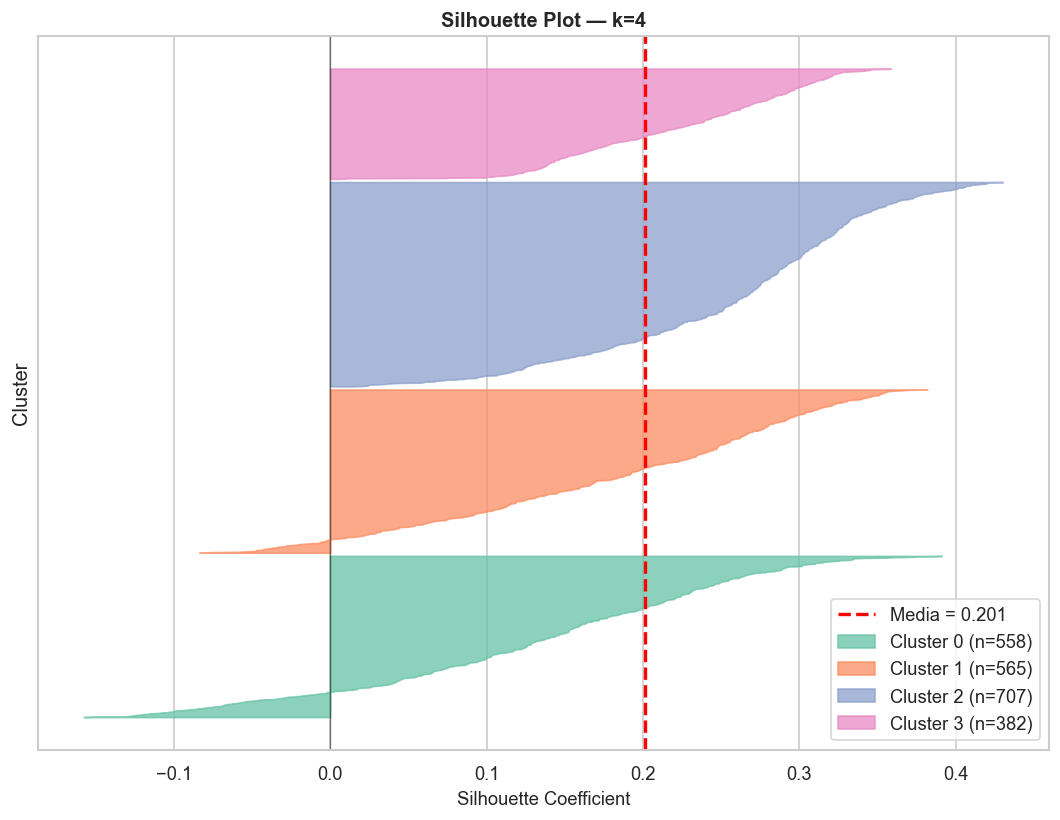

In [37]:
# Silhouette plot
sil_vals = silhouette_samples(X_pca, cluster_labels)
y_lower = 10

fig, ax = plt.subplots(figsize=(9, 7))
ax.axvline(x=sil_final, color='red', linestyle='--', linewidth=2,
           label=f'Media = {sil_final:.3f}')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

palette_sil = sns.color_palette('Set2', n_colors=OPTIMAL_K)

for c in range(OPTIMAL_K):
    c_vals = np.sort(sil_vals[cluster_labels == c])
    size = len(c_vals)
    y_upper = y_lower + size
    color = palette_sil[c]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_vals,
                     alpha=0.75, color=color, label=f'Cluster {c} (n={size})')
    y_lower = y_upper + 10

ax.set_xlabel('Silhouette Coefficient', fontsize=11)
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Plot — k={OPTIMAL_K}', fontsize=12, fontweight='bold')
ax.set_yticks([])
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 18. Metadata del Modelo — Reproducibilidad

In [38]:
import sklearn

# Construir metadata
model_metadata = {
    'training_date': datetime.now().isoformat(),
    'dataset_shape_original': tuple(df_raw.shape),
    'dataset_shape_final': tuple(df_original.shape),
    'n_clusters': int(OPTIMAL_K),
    'premium_cluster': int(premium_cluster),
    'n_pca_components': int(N_COMPONENTS),
    'pca_variance_explained': float(pca.explained_variance_ratio_.sum()),
    'n_features_clustering': len(feature_names_clustering),
    'features_used': feature_names_clustering,
    'features_excluded': features_to_exclude,
    'preprocessing': {
        'outliers_removed': int(n_outliers),
        'outlier_threshold': f'Q3 + 3*IQR = {fence_upper:.0f}€'
    },
    'validation_metrics': {
        'silhouette_score': float(sil_final),
        'davies_bouldin_index': float(dbi_final),
        'calinski_harabasz_index': float(chi_final),
        'ari_stability_mean': float(ari_mean),
        'ari_stability_std': float(ari_std)
    },
    'sklearn_version': sklearn.__version__,
    'random_seed': 42,
    'models_saved': {
        'scaler': 'scaler.pkl',
        'pca': 'pca.pkl',
        'kmeans': 'kmeans_model.pkl',
        'gaussian_mixture': 'gaussian_mixture_model.pkl',
        'random_forest': 'random_forest_model.pkl',
        'encoder_education': 'encoder_education.pkl'
    }
}

# Guardar metadata
metadata_path = MODEL_DIR / 'model_metadata.json'
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(model_metadata, f, indent=2, ensure_ascii=False)

print('[OK] Metadata del modelo guardada')
print()
print('=== METADATA DEL MODELO ===')
print(json.dumps(model_metadata, indent=2, ensure_ascii=False))

[OK] Metadata del modelo guardada

=== METADATA DEL MODELO ===
{
  "training_date": "2026-07-28T22:01:27.744538",
  "dataset_shape_original": [
    2240,
    29
  ],
  "dataset_shape_final": [
    2212,
    26
  ],
  "n_clusters": 4,
  "premium_cluster": 1,
  "n_pca_components": 8,
  "pca_variance_explained": 0.8295011620654281,
  "n_features_clustering": 19,
  "features_used": [
    "Income",
    "Recency",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "Age",
    "TotalSpend",
    "TotalPurchases",
    "TotalAcceptedCmps",
    "HasPartner",
    "FamilySize"
  ],
  "features_excluded": [
    "CustomerSince",
    "Complain"
  ],
  "preprocessing": {
    "outliers_removed": 1,
    "outlier_threshold": "Q3 + 3*IQR = 168179€"
  },
  "validation_metrics": {
    "silhouette_score": 0.20124